In [1]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Directory setup
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Tufte-compliant style
plt.style.use('default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['figure.dpi'] = 150

# CORRECTED STAGE 2 CONSTANTS
gb_thermal_cost = 1039607071
gb_thermal_volume = 6304728  # 6.30 TWh
scotland_cost_share = 0.477
scotland_thermal_cost = 495740787  # ~£495.7M
scotland_thermal_volume = 3006435  # 3.01 TWh
avg_cost_proxy = 164.89  # £/MWh

print(f"✅ Setup complete. Figures will be saved to: {FIGURES_DIR.absolute()}/")

✅ Setup complete. Figures will be saved to: /home/ndrew/scotland-ai-split-zones/notebooks/figures/


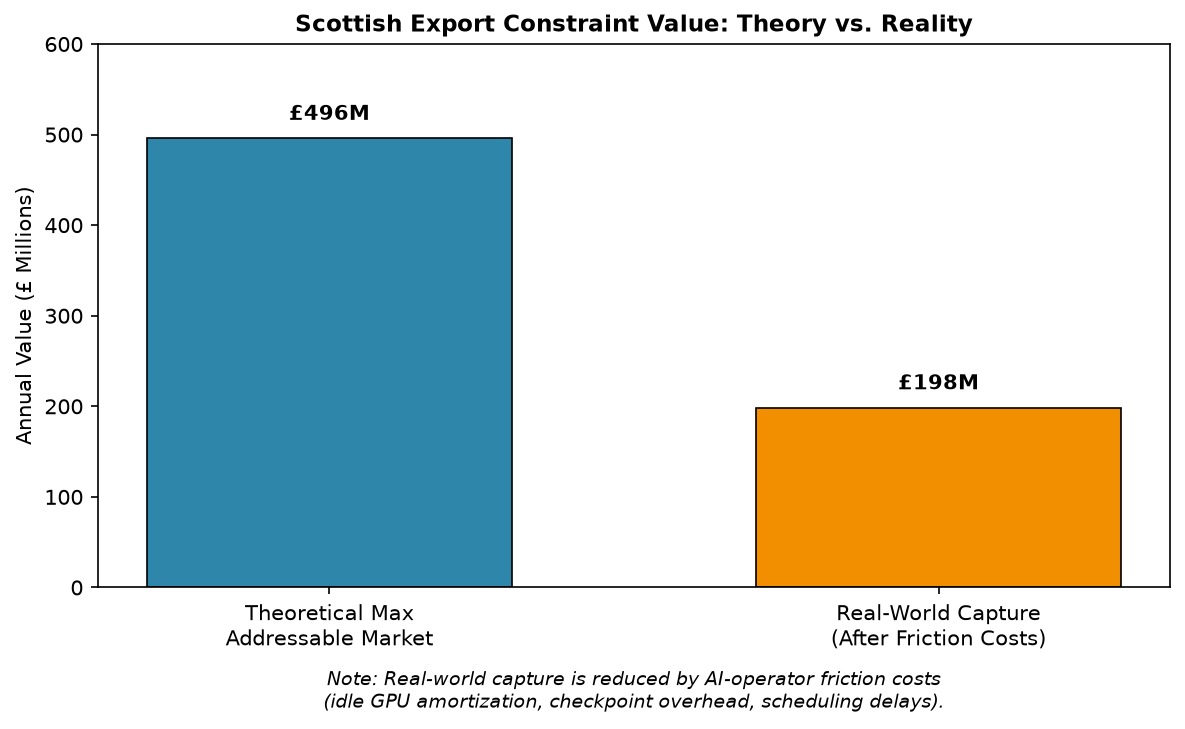

✅ Saved to: figures/05_theoretical_vs_real_capture.png


In [2]:
# =============================================================================
# Figure 1: Theoretical Max vs. Real-World Friction
# =============================================================================
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

categories = ['Theoretical Max\nAddressable Market', 'Real-World Capture\n(After Friction Costs)']
values = [scotland_thermal_cost / 1e6, (scotland_thermal_cost / 1e6) * 0.4] # 40% is a conservative illustrative capture rate
colors = ['#2E86AB', '#F18F01']

bars = ax.bar(categories, values, color=colors, edgecolor='black', linewidth=0.8, width=0.6)
ax.set_ylabel('Annual Value (£ Millions)', fontsize=10)
ax.set_ylim(0, 600)
ax.set_title('Scottish Export Constraint Value: Theory vs. Reality', fontsize=11, fontweight='bold')

# Add value labels
for bar, val in zip(bars, values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 15,
            f'£{val:.0f}M', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Add caveat annotation
ax.text(0.5, -0.15, 
        'Note: Real-world capture is reduced by AI-operator friction costs\n(idle GPU amortization, checkpoint overhead, scheduling delays).', 
        ha='center', va='top', fontsize=9, style='italic', transform=ax.transAxes)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '05_theoretical_vs_real_capture.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Saved to: {FIGURES_DIR / '05_theoretical_vs_real_capture.png'}")

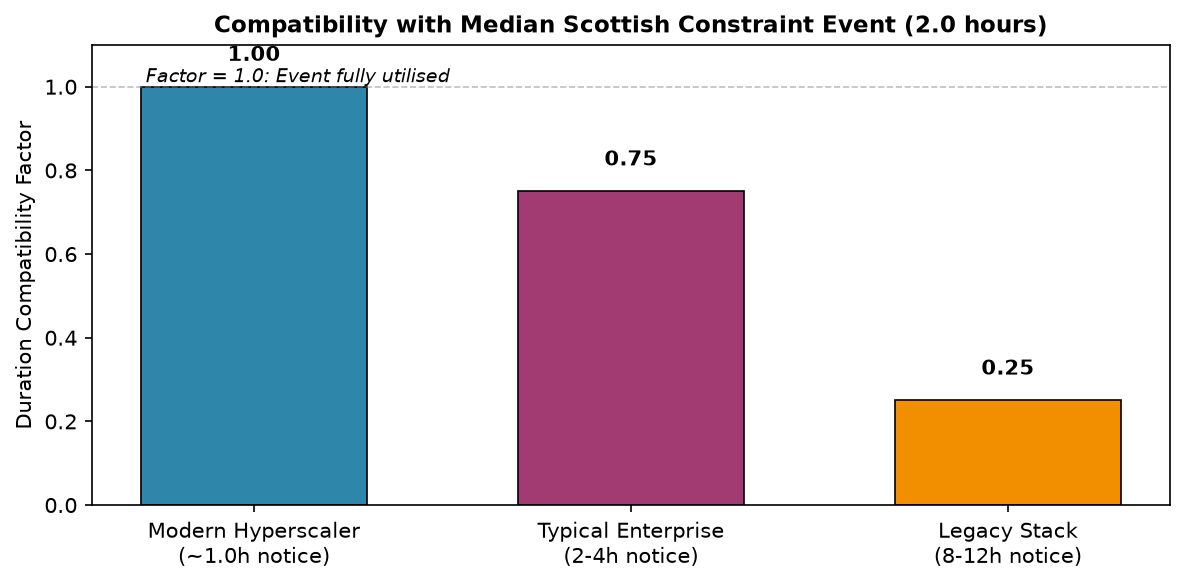

✅ Saved to: figures/05_duration_compatibility.png


In [3]:
# =============================================================================
# Figure 2: Duration Compatibility Factor
# =============================================================================
fig, ax = plt.subplots(1, 1, figsize=(8, 4))

practices = ['Modern Hyperscaler\n(~1.0h notice)', 'Typical Enterprise\n(2-4h notice)', 'Legacy Stack\n(8-12h notice)']
# Compatibility factor for a 2.0h median event: min(1, 2.0 / notice)
factors = [1.0, 0.75, 0.25] 
colors = ['#2E86AB', '#A23B72', '#F18F01']

bars = ax.bar(practices, factors, color=colors, edgecolor='black', linewidth=0.8, width=0.6)
ax.set_ylabel('Duration Compatibility Factor', fontsize=10)
ax.set_ylim(0, 1.1)
ax.set_title('Compatibility with Median Scottish Constraint Event (2.0 hours)', fontsize=11, fontweight='bold')

# Add value labels
for bar, factor in zip(bars, factors):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.05,
            f'{factor:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Add interpretation line
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.text(0.05, 0.95, 'Factor = 1.0: Event fully utilised', ha='left', va='top', fontsize=9, style='italic', transform=ax.transAxes)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '05_duration_compatibility.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Saved to: {FIGURES_DIR / '05_duration_compatibility.png'}")

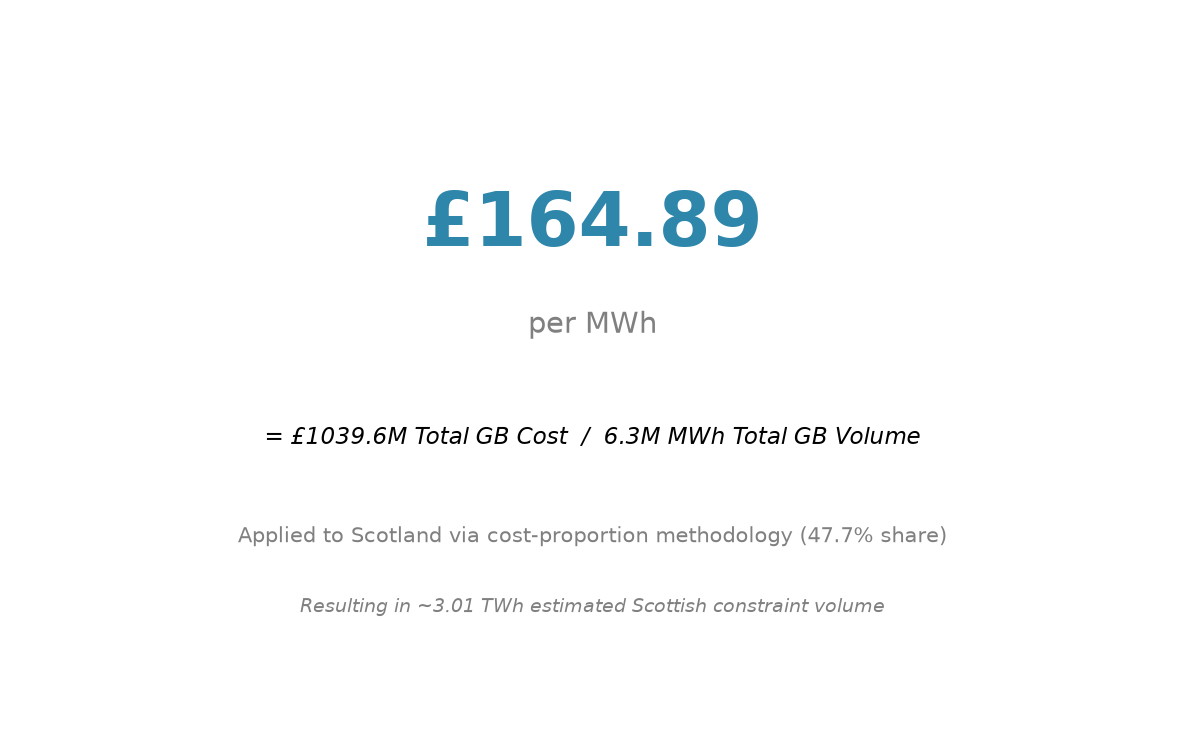

✅ Saved to: figures/05_cost_proxy_methodology.png


In [4]:
# =============================================================================
# Figure 3: Cost per MWh Proxy (Methodology)
# =============================================================================
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

ax.set_xlim(0, 10)
ax.set_ylim(0, 5)
ax.axis('off')

# Main value
ax.text(5, 3.5, f'£{avg_cost_proxy:.2f}', ha='center', va='center', 
        fontsize=36, fontweight='bold', color='#2E86AB')
ax.text(5, 2.8, 'per MWh', ha='center', va='center', 
        fontsize=14, color='gray')

# Formula
ax.text(5, 2.0, f'= £{(gb_thermal_cost/1e6):.1f}M Total GB Cost  /  {(gb_thermal_volume/1e6):.1f}M MWh Total GB Volume', 
        ha='center', va='center', fontsize=11, style='italic')

# Context
ax.text(5, 1.3, 'Applied to Scotland via cost-proportion methodology (47.7% share)', 
        ha='center', va='center', fontsize=10, color='gray')
ax.text(5, 0.8, 'Resulting in ~3.01 TWh estimated Scottish constraint volume', 
        ha='center', va='center', fontsize=9, style='italic', color='gray')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '05_cost_proxy_methodology.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Saved to: {FIGURES_DIR / '05_cost_proxy_methodology.png'}")